AirSight — Operational Pressure Clustering

This notebook explores historical airport activity patterns to define operational pressure levels such as **Normal, High, and Extreme**.

The clustering is built independently from the forecasting models. Later, the resulting pressure definition will be connected to the predicted traffic for the next three hours.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

## 0. Load the Model-Ready Dataset

The traffic-only dataset is used because operational pressure should first be defined from airport activity rather than weather conditions.

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
df = pd.read_csv("/content/drive/MyDrive/AirSight/model_ready_traffic.csv")

df["hour"] = pd.to_datetime(df["hour"])

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (4857, 31)


,hour,flight_count,arrival,departure,terminal_1_count,terminal_2_count,terminal_3_count,terminal_4_count,terminal_5_count,unique_airlines,...,lag_3h,lag_24h,lag_48h,lag_168h,rolling_mean_3h,rolling_mean_24h,rolling_std_24h,target_t1,target_t2,target_t3
0,2025-03-21 21:00:00+00:00,26,14,12,5,2,1,4,14,10,...,31.0,25.0,24.0,26.0,34.000000,25.708333,4.804700,16.0,22.0,27.0
1,2025-03-21 22:00:00+00:00,16,9,7,1,0,3,0,12,7,...,36.0,20.0,20.0,19.0,32.333333,25.750000,4.802626,22.0,27.0,17.0
2,2025-03-21 23:00:00+00:00,22,10,12,2,0,4,6,10,9,...,35.0,20.0,20.0,24.0,25.666667,25.583333,5.072660,27.0,17.0,20.0
3,2025-03-22 00:00:00+00:00,27,18,9,5,0,7,4,11,11,...,26.0,23.0,24.0,22.0,21.333333,25.666667,4.992748,17.0,20.0,25.0
4,2025-03-22 01:00:00+00:00,17,7,10,0,0,5,1,11,8,...,16.0,19.0,20.0,16.0,21.666667,25.833333,4.966555,20.0,25.0,20.0


## 1. Basic Data Check

Before clustering, the dataset is sorted chronologically and checked for missing values and timeline coverage.

In [43]:
df = df.sort_values("hour").reset_index(drop=True)

print("Date range:")
print(df["hour"].min(), "→", df["hour"].max())

print("\nMissing values:")
display(
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

Date range:
2025-03-21 21:00:00+00:00 → 2025-10-10 05:00:00+00:00

Missing values:


,0
hour,0
flight_count,0
arrival,0
departure,0
terminal_1_count,0
terminal_2_count,0
terminal_3_count,0
terminal_4_count,0
terminal_5_count,0
unique_airlines,0


The model-ready dataset contains no remaining missing values in the selected period.

## 2. Chronological Train / Validation / Test Split

The same 70% / 15% / 15% chronological split used by the forecasting models is kept for consistency.

A 3-hour gap is introduced at the Train/Validation and Validation/Test boundaries to prevent the `t+1`, `t+2`, and `t+3` forecast targets from crossing into the next split.

The clustering model is fitted using the training period only and then applied to later periods.

In [44]:
#train_end = int(n * 0.70)
#val_end = int(n * 0.85)

#train_df = df.iloc[:train_end].copy()
#val_df = df.iloc[train_end:val_end].copy()
#test_df = df.iloc[val_end:].copy()

#modify
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

# Maximum forecast horizon: 3 hours ahead
forecast_horizon = 3

# Chronological split with a 3-hour gap at the boundaries
train_df = df.iloc[
    :train_end - forecast_horizon
].copy()

val_df = df.iloc[
    train_end:val_end - forecast_horizon
].copy()

test_df = df.iloc[
    val_end:
].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain period:")
print(train_df["hour"].min(), "→", train_df["hour"].max())

print("\nValidation period:")
print(val_df["hour"].min(), "→", val_df["hour"].max())

print("\nTest period:")
print(test_df["hour"].min(), "→", test_df["hour"].max())

Train: (3396, 31)
Validation: (726, 31)
Test: (729, 31)

Train period:
2025-03-21 21:00:00+00:00 → 2025-08-10 08:00:00+00:00

Validation period:
2025-08-10 12:00:00+00:00 → 2025-09-09 17:00:00+00:00

Test period:
2025-09-09 21:00:00+00:00 → 2025-10-10 05:00:00+00:00


In [45]:
assert train_df["hour"].max() < val_df["hour"].min()
assert val_df["hour"].max() < test_df["hour"].min()

print("Chronological split verified.")

Chronological split verified.


## 3. Select Features for Operational Pressure

The forecasting dataset contains features for prediction, including lag, rolling, and future target variables. These are useful for forecasting but do not directly describe the airport's current operational state.

For clustering, we select features that represent the activity observed during each hour, such as traffic volume, movement type, terminal activity, and route diversity.

In [46]:
pressure_features = [
    'flight_count',
    'arrival',
    'departure',

    'terminal_1_count',
    'terminal_2_count',
    'terminal_3_count',
    'terminal_4_count',
    'terminal_5_count',

    'unique_airlines',
    'unique_aircraft_models',
    'unique_routes'
]

X_pressure_train = train_df[pressure_features].copy()

print("Pressure features:", len(pressure_features))
display(X_pressure_train.head())

Pressure features: 11


,flight_count,arrival,departure,terminal_1_count,terminal_2_count,terminal_3_count,terminal_4_count,terminal_5_count,unique_airlines,unique_aircraft_models,unique_routes
0,26,14,12,5,2,1,4,14,10,9,18
1,16,9,7,1,0,3,0,12,7,7,10
2,22,10,12,2,0,4,6,10,9,8,17
3,27,18,9,5,0,7,4,11,11,8,17
4,17,7,10,0,0,5,1,11,8,6,12


### 3.1 Feature Relationship Check

Some operational features may represent similar information. Before clustering, we check their correlations to avoid giving the same activity pattern unnecessary weight.

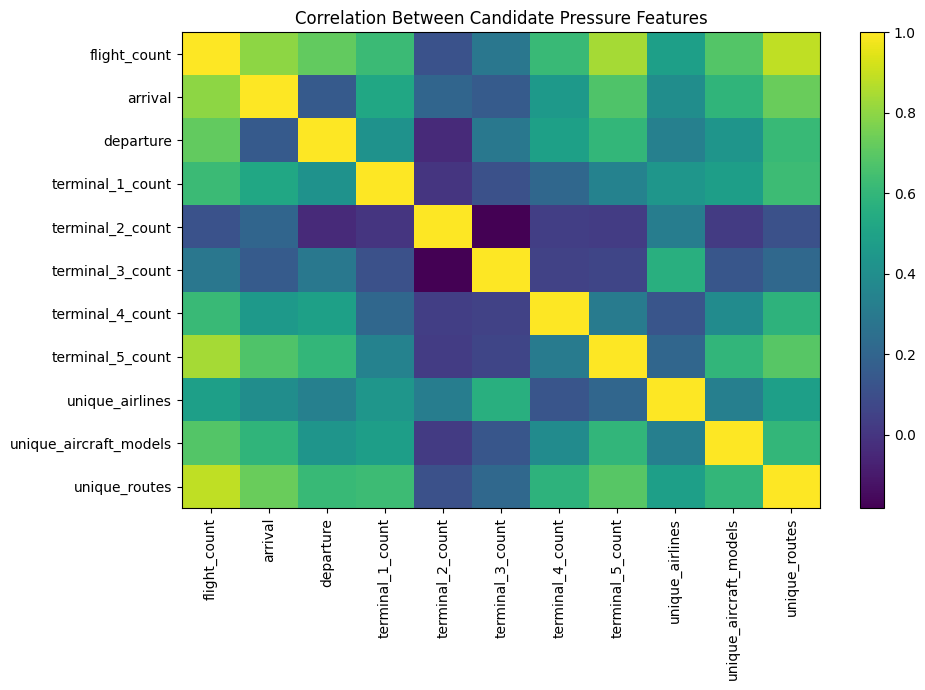

In [47]:
corr = X_pressure_train.corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect='auto')
plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Between Candidate Pressure Features")
plt.tight_layout()
plt.show()

In [48]:
print("Arrival + Departure equals flight_count:",
      ((train_df['arrival'] + train_df['departure']) == train_df['flight_count']).all())

terminal_cols = [
    'terminal_1_count',
    'terminal_2_count',
    'terminal_3_count',
    'terminal_4_count',
    'terminal_5_count'
]

terminal_total = train_df[terminal_cols].sum(axis=1)

print("Terminal counts equal flight_count:",
      (terminal_total == train_df['flight_count']).mean())

Arrival + Departure equals flight_count: True
Terminal counts equal flight_count: 0.848939929328622


### Feature Refinement

`arrival` and `departure` exactly sum to `flight_count`, while terminal counts also reflect much of the same traffic volume.

To avoid giving traffic volume excessive weight in clustering, we keep the total traffic count and derive a few features that describe the composition and distribution of airport activity instead of using all raw counts directly.

In [49]:
terminal_cols = [
    'terminal_1_count',
    'terminal_2_count',
    'terminal_3_count',
    'terminal_4_count',
    'terminal_5_count'
]

for split_df in [train_df, val_df, test_df]:

    # Balance between arrivals and departures
    split_df['arrival_share'] = (
        split_df['arrival'] / split_df['flight_count']
    )

    # Traffic concentration across the known terminals
    terminal_total = split_df[terminal_cols].sum(axis=1)

    split_df['max_terminal_share'] = (
        split_df[terminal_cols].max(axis=1) / terminal_total
    )

In [50]:
pressure_features = [
    'flight_count',
    'arrival_share',
    'max_terminal_share',
    'unique_airlines',
    'unique_aircraft_models'
]

X_pressure_train = train_df[pressure_features].copy()

display(X_pressure_train.describe().T)

,count,mean,std,min,25%,50%,75%,max
flight_count,3396.0,29.681390,7.334733,3.000000,26.000000,31.000000,35.000000,45.000000
arrival_share,3396.0,0.485596,0.140586,0.000000,0.413793,0.484848,0.565217,1.000000
max_terminal_share,3396.0,0.528762,0.086399,0.222222,0.470588,0.527047,0.580645,0.833333
unique_airlines,3396.0,9.330094,1.878407,3.000000,8.000000,9.000000,11.000000,17.000000
unique_aircraft_models,3396.0,8.393698,2.338172,2.000000,7.000000,8.000000,10.000000,16.000000


### 3.2 Final Feature Correlation Check

Before clustering, we check whether the selected features still contain very similar information.

Strongly correlated features can give the same operational pattern more weight in distance-based clustering.

,flight_count,arrival_share,max_terminal_share,unique_airlines,unique_aircraft_models
flight_count,1.00,0.22,-0.02,0.48,0.68
arrival_share,0.22,1.00,-0.01,0.16,0.19
max_terminal_share,-0.02,-0.01,1.00,-0.39,0.02
unique_airlines,0.48,0.16,-0.39,1.00,0.33
unique_aircraft_models,0.68,0.19,0.02,0.33,1.00


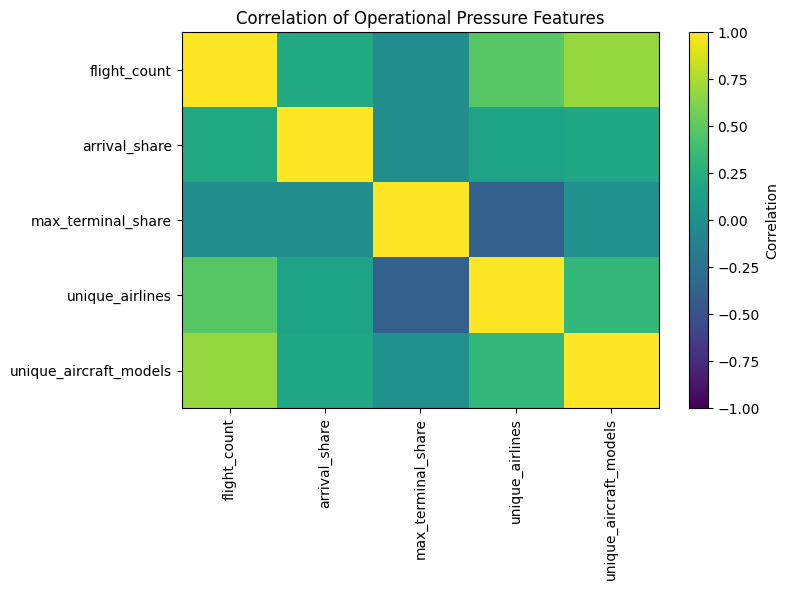

In [51]:
corr = X_pressure_train.corr()

display(corr.round(2))

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation of Operational Pressure Features")
plt.tight_layout()
plt.show()

In [52]:
high_corr = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        value = corr.iloc[i, j]

        if abs(value) >= 0.80:
            high_corr.append({
                "feature_1": corr.columns[i],
                "feature_2": corr.columns[j],
                "correlation": round(value, 3)
            })

pd.DataFrame(high_corr)

""


### Final Feature Selection

Two features were removed before clustering:

- `unique_routes` was strongly correlated with `flight_count` (r = 0.89), so keeping both could give traffic volume excessive weight.
- `active_terminals` showed limited variation, with most hours using four or five terminals.

The final feature set keeps total traffic volume while also describing arrival/departure balance, terminal concentration, airline diversity, and aircraft diversity.

## 4. Feature Scaling

K-Means is distance-based, so features with larger numerical ranges can dominate the clustering.

The scaler is fitted on the training data only, then the same transformation is applied to validation and test data.

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train_df[pressure_features])
X_val_scaled = scaler.transform(val_df[pressure_features])
X_test_scaled = scaler.transform(test_df[pressure_features])

print("Train scaled shape:", X_train_scaled.shape)
print("Validation scaled shape:", X_val_scaled.shape)
print("Test scaled shape:", X_test_scaled.shape)

Train scaled shape: (3396, 5)
Validation scaled shape: (726, 5)
Test scaled shape: (729, 5)


## 5. Choosing the Number of Clusters

To avoid choosing the number of clusters arbitrarily, we compare several values of `k` using:

- **Inertia (Elbow Method):** measures how compact the clusters are.
- **Silhouette Score:** measures how well-separated the clusters are.

The final choice will consider both the metrics and whether the resulting clusters are operationally meaningful.

In [54]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 7)

inertia_scores = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_train_scaled)

    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_train_scaled, labels)
    )

results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia_scores,
    "silhouette_score": silhouette_scores
})

display(results)

,k,inertia,silhouette_score
0,2,12584.130701,0.240017
1,3,10569.211026,0.213309
2,4,8965.993148,0.233190
3,5,7851.354557,0.236388
4,6,6915.982341,0.234922


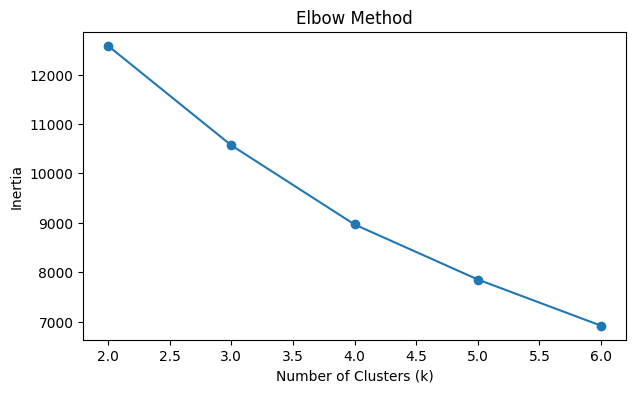

In [55]:
plt.figure(figsize=(7, 4))
plt.plot(results["k"], results["inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

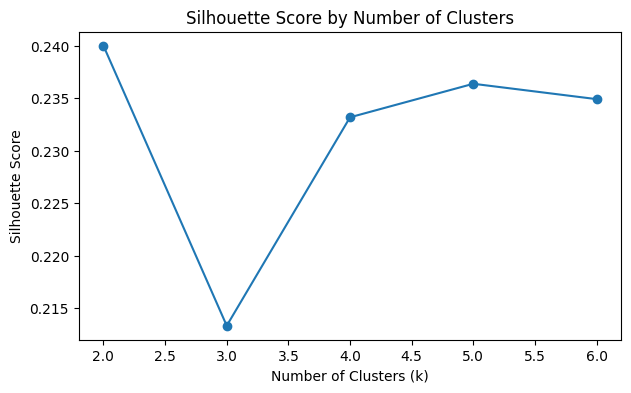

In [56]:
plt.figure(figsize=(7, 4))
plt.plot(results["k"], results["silhouette_score"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

## 6. Inspecting Candidate Cluster Solutions

The clustering metrics do not clearly support three clusters.  
`k=2` gives the highest silhouette score, while `k=4` and `k=5` also provide competitive separation.

Before selecting the final number of clusters, we compare the size and operational profile of several candidate solutions.

In [57]:
candidate_k = [2, 4, 5]

cluster_profiles = {}

for k in candidate_k:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_train_scaled)

    temp = train_df[pressure_features].copy()
    temp["cluster"] = labels

    profile = temp.groupby("cluster").mean().round(2)

    cluster_profiles[k] = profile

    print(f"\nK = {k}")
    print("Cluster sizes:")
    display(temp["cluster"].value_counts().sort_index().to_frame("hours"))

    print("Cluster profile:")
    display(profile)


K = 2
Cluster sizes:


,hours
cluster,
0,1986
1,1410


Cluster profile:


,flight_count,arrival_share,max_terminal_share,unique_airlines,unique_aircraft_models
cluster,,,,,
0,33.94,0.51,0.51,10.21,9.67
1,23.68,0.45,0.55,8.10,6.59



K = 4
Cluster sizes:


...

,flight_count,arrival_share,max_terminal_share,unique_airlines,unique_aircraft_models
cluster,,,,,
0,35.97,0.51,0.52,10.55,10.38
1,13.20,0.03,0.51,6.04,5.39
2,25.88,0.50,0.48,9.63,6.96
3,27.76,0.48,0.62,7.47,7.82



K = 5
Cluster sizes:


,hours
cluster,
0,975
1,297
2,789
3,1036
4,299


Cluster profile:


,flight_count,arrival_share,max_terminal_share,unique_airlines,unique_aircraft_models
cluster,,,,,
0,36.51,0.52,0.51,10.91,10.57
1,20.88,0.71,0.50,8.34,6.60
2,31.97,0.51,0.61,7.89,9.04
3,27.82,0.44,0.48,9.94,7.23
4,16.58,0.26,0.59,6.82,5.43


## 7. Selecting the Final Clustering Solution

Although `k=2` achieved the highest silhouette score, it mainly separated lower and higher traffic periods and was too broad for the operational pressure objective.

`k=5` achieved a similar silhouette score while producing more detailed and interpretable operational patterns. Therefore, five clusters are selected for further analysis.

The clusters will not automatically represent pressure levels. Instead, their operational profiles will be examined and grouped into broader **Normal, High, and Extreme** pressure levels.

In [58]:
final_k = 5

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

train_labels = kmeans.fit_predict(X_train_scaled)

train_df["cluster"] = train_labels

print("Final cluster sizes:")
display(
    train_df["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("hours")
)

Final cluster sizes:


,hours
cluster,
0,975
1,297
2,789
3,1036
4,299


In [59]:
cluster_profile = (
    train_df
    .groupby("cluster")[pressure_features]
    .mean()
    .round(2)
)

display(cluster_profile)

,flight_count,arrival_share,max_terminal_share,unique_airlines,unique_aircraft_models
cluster,,,,,
0,36.51,0.52,0.51,10.91,10.57
1,20.88,0.71,0.50,8.34,6.60
2,31.97,0.51,0.61,7.89,9.04
3,27.82,0.44,0.48,9.94,7.23
4,16.58,0.26,0.59,6.82,5.43


### Cluster Profile Visualization

To better understand how the clusters differ, the average feature values are standardized across clusters and visualized below.

This helps compare the operational characteristics of each cluster beyond traffic volume alone.

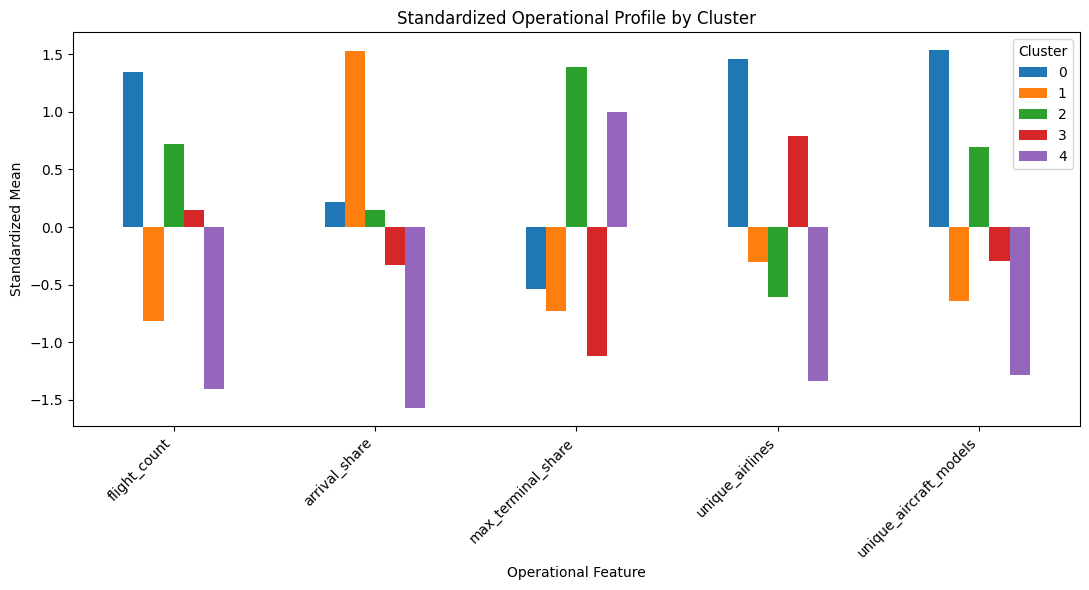

In [60]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Standardize cluster-level averages for easier comparison
profile_scaler = StandardScaler()

cluster_profile_scaled = pd.DataFrame(
    profile_scaler.fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

cluster_profile_scaled.T.plot(
    kind='bar',
    figsize=(11, 6)
)

plt.title('Standardized Operational Profile by Cluster')
plt.xlabel('Operational Feature')
plt.ylabel('Standardized Mean')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

The cluster profiles show that the groups differ in more than traffic volume alone.

Clusters 4 and 1 represent lower-intensity operating conditions, while Clusters 3 and 2 show different mid-level operational patterns. Cluster 0 has the highest traffic volume, airline diversity, and aircraft diversity, supporting its interpretation as the highest-pressure cluster.

## 8. Ranking Clusters by Operational Intensity

Cluster IDs are arbitrary, so they should not be interpreted directly as pressure levels.

To compare the clusters more meaningfully, we rank them using the features that most directly reflect operational intensity:

- `flight_count`
- `unique_airlines`
- `unique_aircraft_models`

`arrival_share` and `max_terminal_share` are kept for interpretation, but they are not used to define intensity because they describe traffic composition rather than overall workload.

In [61]:
intensity_features = [
    'flight_count',
    'unique_airlines',
    'unique_aircraft_models'
]

# Standardize cluster-level means so the three features contribute comparably
profile_scaled = StandardScaler().fit_transform(
    cluster_profile[intensity_features]
)

intensity_scores = profile_scaled.mean(axis=1)

cluster_intensity = cluster_profile.copy()
cluster_intensity['intensity_score'] = intensity_scores

cluster_intensity = cluster_intensity.sort_values(
    'intensity_score'
)

display(cluster_intensity.round(2))

,flight_count,arrival_share,max_terminal_share,unique_airlines,unique_aircraft_models,intensity_score
cluster,,,,,,
4,16.58,0.26,0.59,6.82,5.43,-1.34
1,20.88,0.71,0.50,8.34,6.60,-0.59
3,27.82,0.44,0.48,9.94,7.23,0.21
2,31.97,0.51,0.61,7.89,9.04,0.27
0,36.51,0.52,0.51,10.91,10.57,1.45


## K-Means Stability Check

To check whether the selected clustering solution is sensitive to K-Means initialization, the model is repeated using different random seeds.

A stable solution should produce similar clustering quality across runs.

In [62]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

seeds = [0, 10, 20, 30, 42, 50, 100]

stability_results = []

for seed in seeds:
    model = KMeans(
        n_clusters=5,
        random_state=seed,
        n_init=10
    )

    labels = model.fit_predict(X_train_scaled)

    stability_results.append({
        'random_state': seed,
        'inertia': model.inertia_,
        'silhouette_score': silhouette_score(X_train_scaled, labels)
    })

stability_results = pd.DataFrame(stability_results)

display(stability_results.round(4))

print(
    'Mean silhouette:',
    round(stability_results['silhouette_score'].mean(), 4)
)

print(
    'Std silhouette:',
    round(stability_results['silhouette_score'].std(), 4)
)

,random_state,inertia,silhouette_score
0,0,7851.2543,0.2365
1,10,7851.2486,0.2367
2,20,7851.3484,0.2363
3,30,7851.2486,0.2367
4,42,7851.3546,0.2364
5,50,7851.2617,0.2365
6,100,7851.2486,0.2367


Mean silhouette: 0.2365
Std silhouette: 0.0001


The K-Means solution is highly stable across different random initializations.

All tested random seeds produced nearly identical inertia and the same silhouette score (0.2365), with a standard deviation of 0.0.

This indicates that the selected five-cluster solution is not sensitive to initialization.

## 9. Defining Operational Pressure Levels

The cluster intensity scores show three operational groups:

- Clusters 4 and 1 represent lower operational intensity.
- Clusters 3 and 2 represent moderate-to-high operational intensity.
- Cluster 0 represents the highest operational intensity.

Based on this pattern, the five clusters are grouped into three pressure levels:

- **Normal:** Clusters 4 and 1
- **High:** Clusters 3 and 2
- **Extreme:** Cluster 0

Cluster IDs are arbitrary and may change when K-Means is refitted, so the mapping is based on the cluster profiles and intensity ranking rather than the numeric cluster labels.

In [63]:
#pressure_mapping = {
#   0: "Normal",
#   1: "Normal",
#   2: "High",
#    3: "High",
#    4: "Extreme"
#}

#modify
pressure_mapping = {
    4: "Normal",
    1: "Normal",
    3: "High",
    2: "High",
    0: "Extreme"
}

train_df["pressure_level"] = train_df["cluster"].map(pressure_mapping)

display(
    train_df["pressure_level"]
    .value_counts()
    .to_frame("hours")
)

,hours
pressure_level,
High,1825
Extreme,975
Normal,596


In [64]:
pressure_distribution = (
    train_df["pressure_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .to_frame("percentage")
)

display(pressure_distribution)

,percentage
pressure_level,
High,53.7
Extreme,28.7
Normal,17.6


## 10. Applying the Pressure Definition to Validation and Test Data

The scaler and K-Means model were fitted using the training period only.

The same transformations and cluster definitions are now applied to the validation and test periods to check whether the operational pressure structure remains meaningful on later unseen data.

In [65]:
val_df["cluster"] = kmeans.predict(X_val_scaled)
test_df["cluster"] = kmeans.predict(X_test_scaled)

val_df["pressure_level"] = val_df["cluster"].map(pressure_mapping)
test_df["pressure_level"] = test_df["cluster"].map(pressure_mapping)

print("Validation pressure distribution:")
display(
    val_df["pressure_level"]
    .value_counts()
    .to_frame("hours")
)

print("Test pressure distribution:")
display(
    test_df["pressure_level"]
    .value_counts()
    .to_frame("hours")
)

Validation pressure distribution:


,hours
pressure_level,
High,348
Extreme,280
Normal,98


Test pressure distribution:


,hours
pressure_level,
High,398
Extreme,212
Normal,119


### Pressure Distribution Check

The pressure-level distribution remains reasonably consistent across the three time periods.

The test distribution is especially close to the training distribution, while the validation period contains a somewhat higher proportion of Extreme-pressure hours. Overall, the learned pressure structure remains present in unseen periods.

### Pressure Level Validation

To confirm that the pressure labels reflect increasing operational intensity, we compare the average hourly traffic across the three pressure levels in the training, validation, and test periods.

In [66]:
for name, split_df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}")

    display(
        split_df
        .groupby("pressure_level")["flight_count"]
        .mean()
        .reindex(["Normal", "High", "Extreme"])
        .round(2)
        .to_frame("avg_flight_count")
    )


Train


,avg_flight_count
pressure_level,
Normal,18.72
High,29.61
Extreme,36.51



Validation


,avg_flight_count
pressure_level,
Normal,20.32
High,30.46
Extreme,37.44



Test


,avg_flight_count
pressure_level,
Normal,20.07
High,30.44
Extreme,36.88


The pressure levels show a consistent increase in hourly traffic across all three periods:

**Normal < High < Extreme**

This supports the interpretation that the derived pressure labels represent increasing operational intensity and remain stable on unseen data.

## Time-Relative Traffic Analysis

A fixed number of hourly movements does not necessarily represent the same operational condition at every time of day.

To add temporal context, we compare each hour's traffic with the typical traffic observed during the same hour of day and day of week in the training period.

This analysis does not represent airport capacity. It provides an additional historical context for identifying unusually high activity relative to normal traffic patterns.

In [67]:
# Create local calendar features if they are not already available
for split_df in [train_df, val_df, test_df]:
    local_time = split_df["hour"].dt.tz_convert("Asia/Riyadh")
    split_df["hour_of_day"] = local_time.dt.hour
    split_df["day_of_week"] = local_time.dt.dayofweek

# Typical traffic for each hour-of-day × day-of-week combination
traffic_baseline = (
    train_df
    .groupby(["day_of_week", "hour_of_day"])["flight_count"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={
        "mean": "expected_traffic",
        "std": "traffic_std"
    })
)

display(traffic_baseline.head())

,day_of_week,hour_of_day,expected_traffic,traffic_std
0,0,0,12.10,8.849026
1,0,1,14.15,6.217759
2,0,2,20.30,1.838191
3,0,3,17.55,2.012461
4,0,4,16.85,2.230766


In [68]:
def add_relative_traffic_features(df, baseline):

    result = df.merge(
        baseline,
        on=["day_of_week", "hour_of_day"],
        how="left"
    )

    result["traffic_deviation"] = (
        result["flight_count"] - result["expected_traffic"]
    )

    result["traffic_zscore"] = (
        result["traffic_deviation"] / result["traffic_std"]
    )

    return result


train_df = add_relative_traffic_features(train_df, traffic_baseline)
val_df = add_relative_traffic_features(val_df, traffic_baseline)
test_df = add_relative_traffic_features(test_df, traffic_baseline)

In [69]:
relative_pressure_summary = (
    train_df
    .groupby("pressure_level")
    [["flight_count", "expected_traffic", "traffic_deviation", "traffic_zscore"]]
    .mean()
    .reindex(["Normal", "High", "Extreme"])
    .round(2)
)

display(relative_pressure_summary)

,flight_count,expected_traffic,traffic_deviation,traffic_zscore
pressure_level,,,,
Normal,18.72,21.98,-3.26,-0.77
High,29.61,29.29,0.32,0.06
Extreme,36.51,35.12,1.39,0.37


In [70]:
for name, split_df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}")

    display(
        split_df
        .groupby("pressure_level")
        [["traffic_deviation", "traffic_zscore"]]
        .mean()
        .reindex(["Normal", "High", "Extreme"])
        .round(2)
    )


Train


,traffic_deviation,traffic_zscore
pressure_level,,
Normal,-3.26,-0.77
High,0.32,0.06
Extreme,1.39,0.37



Validation


,traffic_deviation,traffic_zscore
pressure_level,,
Normal,-0.53,-0.46
High,2.13,0.61
Extreme,2.88,0.86



Test


,traffic_deviation,traffic_zscore
pressure_level,,
Normal,-0.62,-0.23
High,1.27,0.34
Extreme,1.31,0.45


### Interpretation

The time-relative analysis shows a consistent pattern across the chronological splits.

Normal-pressure periods tend to have traffic below the historical expectation for the same hour and day, while High and Extreme periods generally occur at or above the expected traffic level.

This provides additional temporal context for the pressure definition and shows that the identified pressure levels are not based only on fixed hourly traffic counts.

However, the difference between High and Extreme is not always large, so the relative traffic measure is used as supporting analysis rather than as the main pressure definition.

## 11. Deriving Traffic-Based Pressure Thresholds

The clustering model uses several operational features, while the forecasting models predict future `flight_count`.

To connect the two stages, we derive a simple traffic-based rule that approximates the cluster-derived pressure labels using `flight_count` only.

The rule is learned from the training period only and then evaluated on validation and test data.

In [71]:
pressure_traffic_summary = (
    train_df
    .groupby("pressure_level")["flight_count"]
    .agg(["min", "mean", "median", "max"])
    .reindex(["Normal", "High", "Extreme"])
    .round(2)
)

display(pressure_traffic_summary)

,min,mean,median,max
pressure_level,,,,
Normal,3,18.72,18.0,34
High,9,29.61,30.0,41
Extreme,25,36.51,36.0,45


### Learning an Interpretable Pressure Rule

A shallow decision tree is used to approximate the cluster-derived pressure levels from hourly traffic alone.

The tree is intentionally kept simple so that the resulting thresholds can later be applied directly to the traffic forecasts.

In [72]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

X_rule_train = train_df[["flight_count"]]
y_rule_train = train_df["pressure_level"]

pressure_rule = DecisionTreeClassifier(
    max_depth=2,
    min_samples_leaf=50,
    random_state=42
)

pressure_rule.fit(X_rule_train, y_rule_train)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=50, random_state=42)

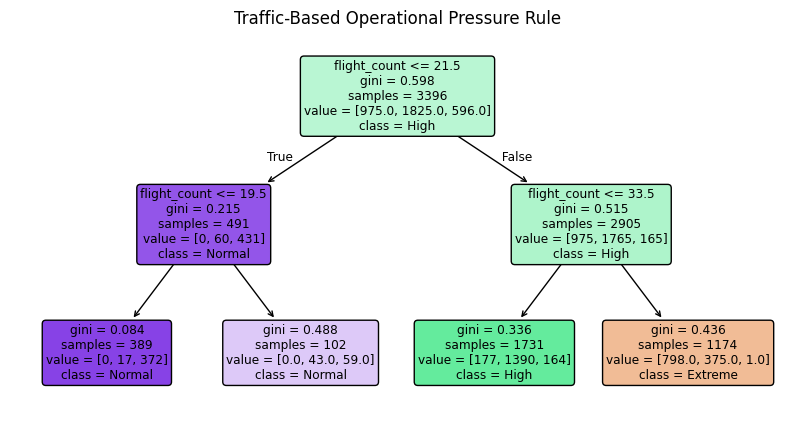

In [73]:
plt.figure(figsize=(10, 5))

plot_tree(
    pressure_rule,
    feature_names=["flight_count"],
    class_names=pressure_rule.classes_,
    filled=True,
    rounded=True
)

plt.title("Traffic-Based Operational Pressure Rule")
plt.show()

### Traffic-Based Pressure Rule

The simplified decision tree produced two practical traffic thresholds:

- **Normal:** 21 or fewer movements per hour
- **High:** 22–33 movements per hour
- **Extreme:** 34 or more movements per hour

These thresholds approximate the cluster-derived pressure levels using `flight_count` only. Some overlap between the original pressure groups is expected because the clustering model also considers airline diversity, aircraft diversity, traffic composition, and terminal concentration.

## Pressure Threshold Refinement

The initial traffic thresholds were derived from a shallow decision tree.

To improve the simplified rule without using the test set, nearby threshold combinations are evaluated on the validation set.

The final thresholds are selected based on a balance between Macro F1 and High-Pressure Detection Rate.

In [74]:
from sklearn.metrics import f1_score
import pandas as pd

def apply_pressure_rule(flight_counts, normal_max, high_max):
    return pd.Series(
        [
            "Normal" if x <= normal_max
            else "High" if x <= high_max
            else "Extreme"
            for x in flight_counts
        ],
        index=flight_counts.index
    )

threshold_results = []

# Search around the original thresholds only
for normal_max in range(19, 24):
    for high_max in range(31, 36):

        if normal_max >= high_max:
            continue

        val_pred = apply_pressure_rule(
            val_df["flight_count"],
            normal_max,
            high_max
        )

        macro_f1 = f1_score(
            val_df["pressure_level"],
            val_pred,
            average="macro"
        )

        high_true = val_df["pressure_level"].isin(["High", "Extreme"])
        high_pred = val_pred.isin(["High", "Extreme"])

        detection_rate = (
            (high_true & high_pred).sum()
            / high_true.sum()
        )

        threshold_results.append({
            "normal_max": normal_max,
            "high_max": high_max,
            "macro_f1": macro_f1,
            "high_pressure_detection_rate": detection_rate
        })

threshold_results = pd.DataFrame(threshold_results)

display(
    threshold_results
    .sort_values(
        ["macro_f1", "high_pressure_detection_rate"],
        ascending=False
    )
    .head(10)
    .round(3)
)

,normal_max,high_max,macro_f1,high_pressure_detection_rate
13,21,34,0.779,0.987
8,20,34,0.778,0.995
12,21,33,0.770,0.987
7,20,33,0.770,0.995
14,21,35,0.767,0.987
9,20,35,0.767,0.995
11,21,32,0.757,0.987
6,20,32,0.757,0.995
18,22,34,0.755,0.967
3,19,34,0.752,0.998


In [75]:
from sklearn.metrics import classification_report, confusion_matrix

candidate_rules = {
    "Original (21, 33)": (21, 33),
    "Candidate (21, 34)": (21, 34),
    "Alternative (20, 34)": (20, 34)
}

for name, (normal_max, high_max) in candidate_rules.items():

    pred = apply_pressure_rule(
        val_df["flight_count"],
        normal_max,
        high_max
    )

    print(f"\n{name}")
    print("-" * 45)

    print(
        classification_report(
            val_df["pressure_level"],
            pred,
            labels=["Normal", "High", "Extreme"],
            digits=3
        )
    )

    print("Confusion matrix:")
    print(
        confusion_matrix(
            val_df["pressure_level"],
            pred,
            labels=["Normal", "High", "Extreme"]
        )
    )


Original (21, 33)
---------------------------------------------
              precision    recall  f1-score   support

      Normal      0.895     0.694     0.782        98
        High      0.793     0.693     0.739       348
     Extreme      0.714     0.882     0.789       280

    accuracy                          0.766       726
   macro avg      0.800     0.756     0.770       726
weighted avg      0.776     0.766     0.764       726

Confusion matrix:
[[ 68  30   0]
 [  8 241  99]
 [  0  33 247]]

Candidate (21, 34)
---------------------------------------------
              precision    recall  f1-score   support

      Normal      0.895     0.694     0.782        98
        High      0.780     0.744     0.762       348
     Extreme      0.745     0.846     0.793       280

    accuracy                          0.777       726
   macro avg      0.807     0.762     0.779       726
weighted avg      0.782     0.777     0.776       726

Confusion matrix:
[[ 68  30   0]
 [  8 259 

### Final Pressure Thresholds

The validation search identified `(21, 34)` as the best overall threshold combination for approximating the cluster-derived pressure labels.

The final traffic-based pressure rule is:

- **Normal:** 21 or fewer movements per hour
- **High:** 22–34 movements per hour
- **Extreme:** 35 or more movements per hour

These thresholds were selected using the validation set only. The test set is reserved for final evaluation.

## Final Test Evaluation

After selecting the final thresholds using the validation set, the rule is evaluated once on the unseen test set.

The test set was not used during threshold selection.

In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Apply final pressure rule to the test set
test_pred_final = apply_pressure_rule(
    test_df["flight_count"],
    normal_max=21,
    high_max=34
)

# Final classification metrics
final_accuracy = accuracy_score(
    test_df["pressure_level"],
    test_pred_final
)

final_precision = precision_score(
    test_df["pressure_level"],
    test_pred_final,
    average="macro"
)

final_recall = recall_score(
    test_df["pressure_level"],
    test_pred_final,
    average="macro"
)

final_f1 = f1_score(
    test_df["pressure_level"],
    test_pred_final,
    average="macro"
)

print("Final Test Results")
print("------------------")
print(f"Accuracy:        {final_accuracy:.3f}")
print(f"Macro Precision: {final_precision:.3f}")
print(f"Macro Recall:    {final_recall:.3f}")
print(f"Macro F1:        {final_f1:.3f}")

Final Test Results
------------------
Accuracy:        0.761
Macro Precision: 0.772
Macro Recall:    0.743
Macro F1:        0.751


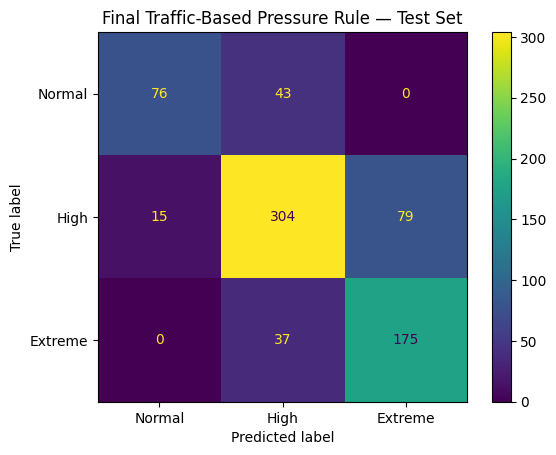

In [77]:
labels = ["Normal", "High", "Extreme"]

cm = confusion_matrix(
    test_df["pressure_level"],
    test_pred_final,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Final Traffic-Based Pressure Rule — Test Set")
plt.show()

In [78]:
high_pressure_true = test_df["pressure_level"].isin(
    ["High", "Extreme"]
)

high_pressure_pred = test_pred_final.isin(
    ["High", "Extreme"]
)

final_detection_rate = (
    (high_pressure_true & high_pressure_pred).sum()
    / high_pressure_true.sum()
)

print(
    f"Final High-Pressure Detection Rate: "
    f"{final_detection_rate:.3f}"
)

Final High-Pressure Detection Rate: 0.975


### Final Evaluation Summary

On the unseen test set, the final traffic-based pressure rule achieved:

- Accuracy: **0.761**
- Macro Precision: **0.772**
- Macro Recall: **0.743**
- Macro F1: **0.751**
- High-Pressure Detection Rate: **97.5%**

Most remaining errors occur between neighboring pressure levels. This is expected because the original pressure labels are derived from multiple operational features, while the simplified rule uses only hourly traffic volume.

The final rule is:

- **Normal:** 21 or fewer movements/hour
- **High:** 22–34 movements/hour
- **Extreme:** 35 or more movements/hour

### Limitations

The pressure levels represent an operational pressure proxy derived from the available airport activity data, rather than direct airport congestion or capacity utilization.

Direct operational indicators such as runway capacity, gate occupancy, actual delays, and ATC staffing were not available in the dataset. Weather is evaluated separately as an additional forecasting experiment rather than being included in the core pressure definition.

### Integration with the Forecasting System

The final pressure rule is now ready to be applied to the `t+1`, `t+2`, and `t+3` traffic forecasts.

The final end-to-end evaluation will measure how well the forecasting system detects future High and Extreme pressure periods.